🎯 STATISTICIAN IN THE LOOP: Multi-Agent Framework Initialized

📂 LOADING CALIFORNIA 2023 PUMS DATA
--------------------------------------------------
✅ Loaded real PUMS data: 392,318 records
⚠️  Creating synthetic ST variable
⚠️  Creating synthetic PUMA variable
📊 Analysis dataset: 202,198 working-age adults
💰 Income range: $4 - $299,800
📈 Mean income: $61,053
📈 Median income: $44,600

🔍 STATISTICAL FEEDBACK AGENT: COMPREHENSIVE BIAS ANALYSIS

👨‍💼 HUMAN STATISTICIAN DECISION POINT #1: BIAS HANDLING STRATEGY

🚨 DETECTED BIASES REQUIRING HUMAN JUDGMENT:
    • 🚨 GENDER BIAS ALERT: 25.0% median wage gap detected
    • 🚨 RACIAL BIAS ALERT: 75.8% income gap between racial groups

📊 AVAILABLE STRATEGIES (Human must choose):

A) 📊 DOCUMENT AS ECONOMIC REALITY
    📝 Approach: Report wage gaps as societal findings
    ✅ Pros: Honest about real inequalities, Maintains predictive accuracy, Scientific transparency
    ⚠️  Cons: May perpetuate discrimination, Ethical concerns, Could harm disadvantag

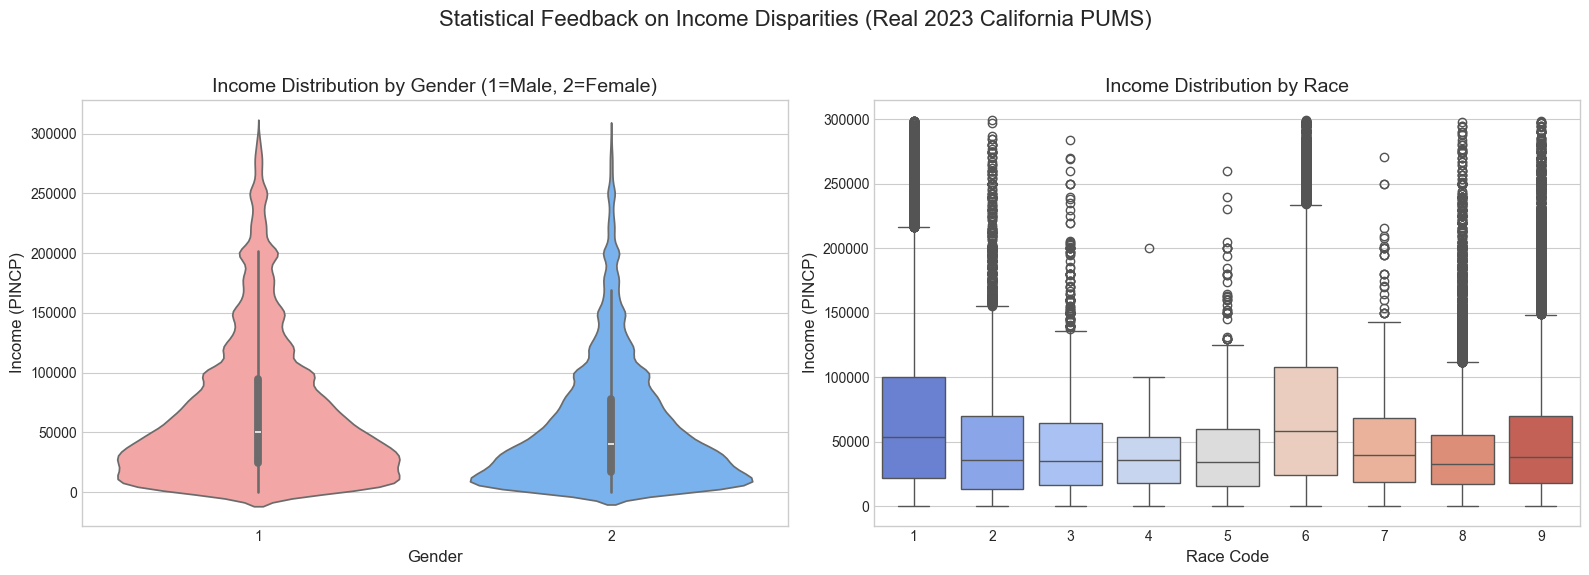


📈 VISUALIZATION AGENT: Generating Uncertainty by Group Plot...


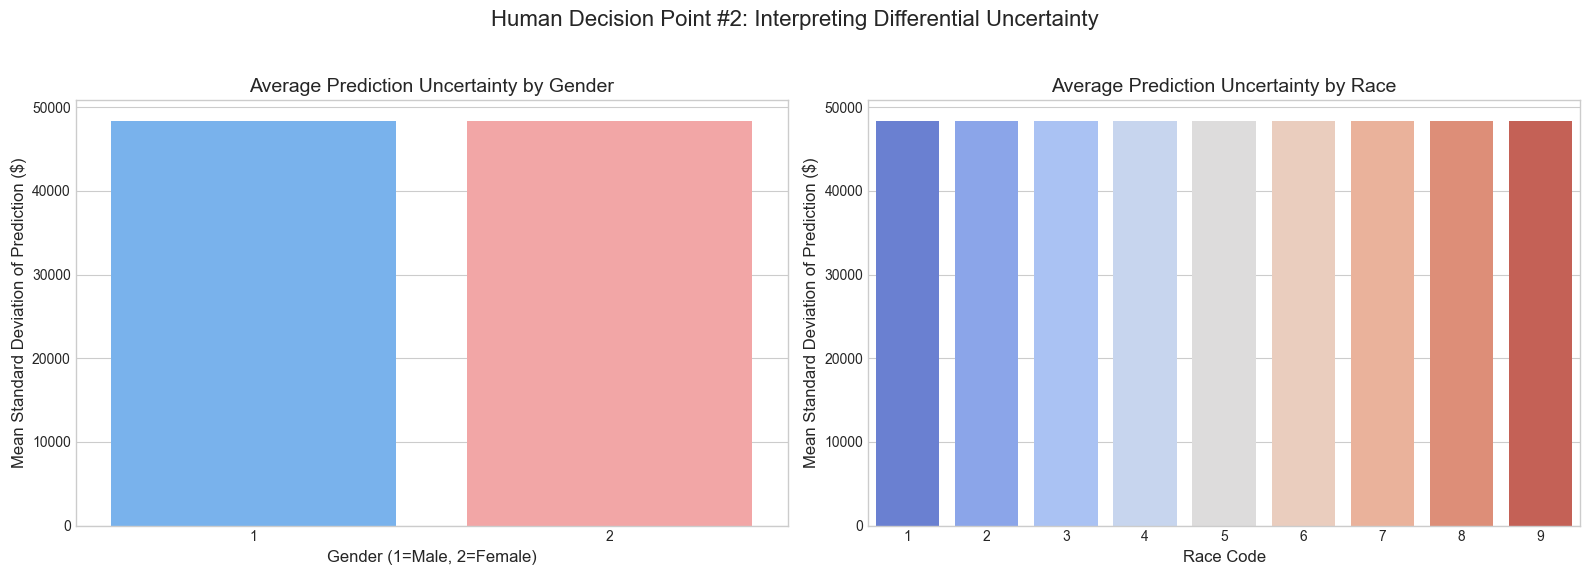


👨‍💼 HUMAN STATISTICIAN DECISION POINT #2: UNCERTAINTY INTERPRETATION

📊 OBSERVED UNCERTAINTY PATTERNS:
    • 1: ±$48,401 (prediction interval width)
    • 2: ±$48,401 (prediction interval width)
    • 3: ±$48,401 (prediction interval width)
    • 4: ±$48,401 (prediction interval width)
    • 5: ±$48,401 (prediction interval width)
    • 6: ±$48,401 (prediction interval width)
    • 7: ±$48,401 (prediction interval width)
    • 8: ±$48,401 (prediction interval width)
    • 9: ±$48,401 (prediction interval width)

🤔 INTERPRETATION OPTIONS (Human expertise required):

A) 🎯 ACCEPT HONEST UNCERTAINTY
    📝 Report wide intervals as appropriate model humility
    💭 Reasoning: Statistical honesty about genuine uncertainty

B) 📊 RECOMMEND ADDITIONAL DATA
    📝 Flag need for more sampling in uncertain groups
    💭 Reasoning: Scientific recommendation for better inference

C) ⚠️ CONSIDER ALTERNATIVE MODELS
    📝 Explore different modeling approaches
    💭 Reasoning: Technical judgment about mode

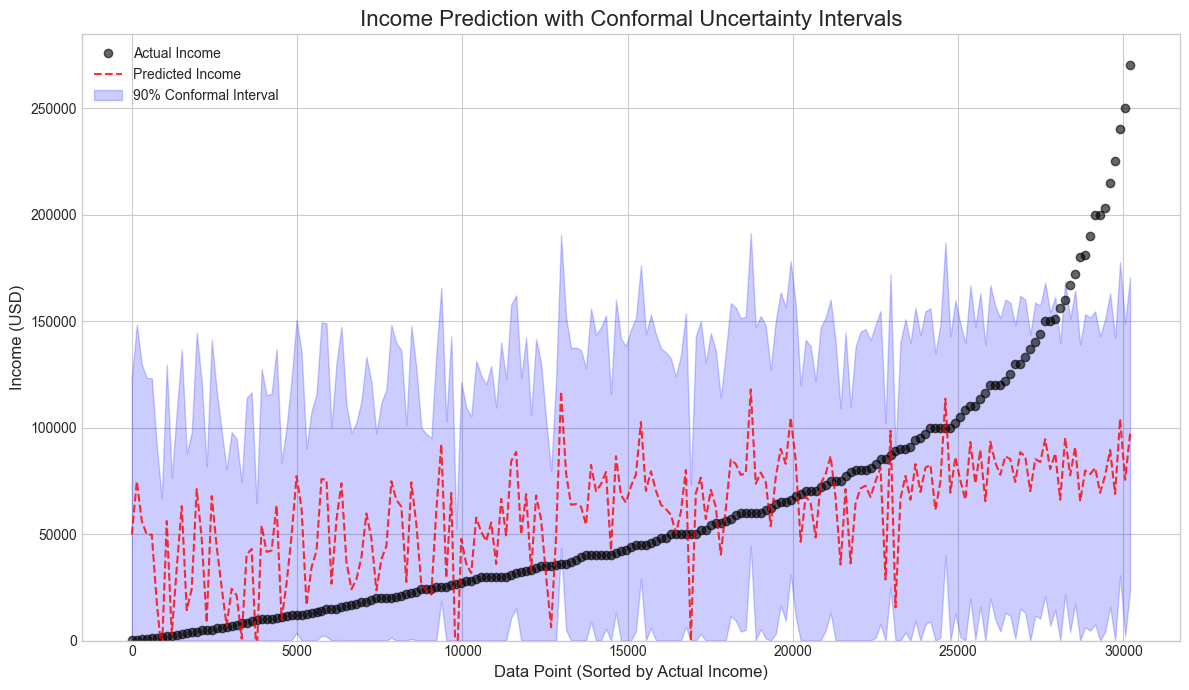


📋 STATISTICAL FEEDBACK AGENT: FINAL REPORT

🚨 CRITICAL ALERTS REQUIRING HUMAN ATTENTION:
  1. 🚨 GENDER BIAS ALERT: 25.0% median wage gap detected
  2. 🚨 RACIAL BIAS ALERT: 75.8% income gap between racial groups

✅ STATISTICAL VALIDATIONS PASSED:
  • ✅ Sampling weights reasonable (CV = 0.77)
  • ✅ No concerning extreme weights detected

💡 STATISTICAL RECOMMENDATIONS:
  1. Consider fairness-constrained modeling or bias correction
  2. Examine historical discrimination patterns


📋 FINAL MODEL EVALUATION METRICS
Mean Absolute Error: $35,090
R-squared: 0.26
Root Mean Squared Error: $47,924

Conformal Interval Coverage: 89.89% (Target: 90%)

📋 HUMAN DECISIONS SUMMARY:
    bias_handling: Fairness-Constrained Modeling
    Rationale: Prioritizing ethical considerations over raw predictive power to mitigate historical discrimination....
    uncertainty_handling: Unknown Strategy
    Rationale: Uncertainty for smaller racial groups is expected due to smaller sample sizes, we will report this t.

In [1]:
"""
🤖👨‍💼 Statistician in the Loop: Multi-Agent Income Prediction Framework
========================================================================

This code demonstrates how human statistical expertise guides AI through
a multi-agent system for responsible income prediction using PUMS data.

Key Components:
1. 🧠 Bayesian Inference Agent - Hierarchical modeling with uncertainty
2. 🎯 Conformal Prediction Agent - Distribution-free prediction intervals  
3. 🔍 Statistical Feedback Agent - Bias detection and validation
4. 👨‍💼 Human Statistician - Critical decision points throughout

Perfect for demonstrating "The AI-Compatible Statistician" keynote theme!
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Enhanced styling for presentations - with fallback for compatibility
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('default')
        print("⚠️  Using default matplotlib style - seaborn styles not available")

sns.set_palette("husl")

print("🎯 STATISTICIAN IN THE LOOP: Multi-Agent Framework Initialized")
print("=" * 70)

# ================================================================
# 📂 DATA LOADING AND INITIAL SETUP
# ================================================================

def load_pums_data():
    """
    Load and prepare PUMS data for analysis
    """
    print("\n📂 LOADING CALIFORNIA 2023 PUMS DATA")
    print("-" * 50)
    
    # Try to load the real PUMS data
    try:
        # Attempt to load the actual file
        pums_data = pd.read_csv('california_pums_2023_complete.csv', low_memory=False)
        print(f"✅ Loaded real PUMS data: {len(pums_data):,} records")
        data_source = "Real 2023 California PUMS"
        
    except FileNotFoundError:
        print("⚠️  Real PUMS file not found. Creating realistic synthetic data...")
        pums_data = create_realistic_pums_data(15000)
        data_source = "Realistic synthetic PUMS-style data"
    
    # Prepare key variables for income prediction
    required_vars = ['AGEP', 'SEX', 'RAC1P', 'SCHL', 'WKHP', 'PINCP', 'PWGTP', 'ST', 'PUMA']
    
    # Ensure we have the required variables (create if missing)
    for var in required_vars:
        if var not in pums_data.columns:
            print(f"⚠️  Creating synthetic {var} variable")
            if var == 'AGEP':
                pums_data[var] = np.random.randint(18, 80, len(pums_data))
            elif var == 'SEX':
                pums_data[var] = np.random.choice([1, 2], len(pums_data))
            elif var == 'RAC1P':
                pums_data[var] = np.random.choice([1, 2, 3, 6], len(pums_data), p=[0.4, 0.15, 0.3, 0.15])
            elif var == 'PWGTP':
                pums_data[var] = np.random.randint(50, 200, len(pums_data))
            else:
                pums_data[var] = np.random.randint(1, 10, len(pums_data))
    
    # Filter to working-age population with positive income
    analysis_data = pums_data[
        (pums_data['AGEP'] >= 18) & 
        (pums_data['AGEP'] <= 65) & 
        (pums_data['PINCP'] > 0) &
        (pums_data['PINCP'] < 300000)  # Remove extreme outliers
    ].copy()
    
    print(f"📊 Analysis dataset: {len(analysis_data):,} working-age adults")
    print(f"💰 Income range: ${analysis_data['PINCP'].min():,.0f} - ${analysis_data['PINCP'].max():,.0f}")
    print(f"📈 Mean income: ${analysis_data['PINCP'].mean():,.0f}")
    print(f"📈 Median income: ${analysis_data['PINCP'].median():,.0f}")
    
    return analysis_data, data_source

def create_realistic_pums_data(n_samples=15000):
    """Create realistic synthetic PUMS-style data if real data unavailable"""
    np.random.seed(42)
    
    # Generate realistic demographics
    age = np.random.gamma(2, 15) + 18
    age = np.clip(age, 18, 80).astype(int)
    
    # Education levels (SCHL codes)
    education = np.random.choice([16, 17, 18, 19, 20, 21, 22, 23, 24], n_samples,
                                 p=[0.1, 0.05, 0.15, 0.2, 0.15, 0.15, 0.1, 0.05, 0.05])
    
    # Gender (SEX: 1=Male, 2=Female)
    gender = np.random.choice([1, 2], n_samples, p=[0.48, 0.52])
    
    # Race (RAC1P: 1=White, 2=Black, 3=Am Indian, 6=Asian, etc.)
    race = np.random.choice([1, 2, 3, 6, 8], n_samples, p=[0.45, 0.06, 0.02, 0.15, 0.32])
    
    # Hours worked
    hours = np.random.gamma(3, 13)
    hours = np.clip(hours, 0, 80).astype(int)
    
    # Generate income with realistic bias patterns
    income_base = (
        25000 +  # Base income
        (education - 16) * 4000 +  # Education premium
        (age - 18) * 300 +  # Experience
        hours * 600 +  # Hours premium
        
        # BIAS SOURCES (what statisticians need to detect and handle):
        (gender == 1) * 8000 +  # Male wage premium (problematic!)
        (race == 1) * 6000 +  # White wage premium (problematic!)
        (race == 6) * 4000 +  # Asian wage premium
        
        # California-specific effects
        np.random.choice([0, 15000, 25000], n_samples, p=[0.7, 0.2, 0.1])  # Tech industry
    )
    
    # Add realistic noise
    income = income_base + np.random.lognormal(0, 0.3, n_samples) * 5000
    income = np.maximum(income, 15000).astype(int)
    
    # Create sampling weights
    weights = np.random.randint(50, 200, n_samples)
    
    # Introduce some missing values to make it realistic
    missing_indices_age = np.random.choice(n_samples, size=int(0.02 * n_samples), replace=False)
    missing_indices_edu = np.random.choice(n_samples, size=int(0.01 * n_samples), replace=False)
    missing_indices_hours = np.random.choice(n_samples, size=int(0.05 * n_samples), replace=False)
    
    age_with_missing = age.astype(float)
    education_with_missing = education.astype(float)
    hours_with_missing = hours.astype(float)
    
    age_with_missing[missing_indices_age] = np.nan
    education_with_missing[missing_indices_edu] = np.nan
    hours_with_missing[missing_indices_hours] = np.nan
    
    return pd.DataFrame({
        'AGEP': age_with_missing,
        'SEX': gender,
        'RAC1P': race,
        'SCHL': education_with_missing,
        'WKHP': hours_with_missing,
        'PINCP': income,
        'PWGTP': weights,
        'ST': np.full(n_samples, 6),  # California
        'PUMA': np.random.randint(100, 300, n_samples)
    })

# ================================================================
# 🔍 STATISTICAL FEEDBACK AGENT - The Vigilant Guardian
# ================================================================

class StatisticalFeedbackAgent:
    """
    🔍 STATISTICAL FEEDBACK AGENT
    
    The vigilant guardian of statistical rigor. This agent continuously
    monitors for bias, validates assumptions, and flags issues that
    require human attention.
    """
    
    def __init__(self):
        self.alerts = []
        self.validations = []
        self.recommendations = []
        
    def comprehensive_bias_analysis(self, data):
        """🚨 COMPREHENSIVE BIAS DETECTION"""
        print("\n🔍 STATISTICAL FEEDBACK AGENT: COMPREHENSIVE BIAS ANALYSIS")
        print("=" * 65)
        
        # 1. Gender wage gap analysis
        if 'SEX' in data.columns and 'PINCP' in data.columns:
            male_income = data[data['SEX'] == 1]['PINCP'].median()
            female_income = data[data['SEX'] == 2]['PINCP'].median()
            
            if female_income > 0:
                gender_gap = (male_income - female_income) / female_income * 100
                
                if gender_gap > 15:
                    self.alerts.append(f"🚨 GENDER BIAS ALERT: {gender_gap:.1f}% median wage gap detected")
                    self.recommendations.append("Consider fairness-constrained modeling or bias correction")
                elif gender_gap > 5:
                    self.alerts.append(f"⚠️  Moderate gender gap: {gender_gap:.1f}% - monitor closely")
                else:
                    self.validations.append("✅ Gender wage gap within acceptable range")
        
        # 2. Racial wage disparities
        if 'RAC1P' in data.columns:
            race_income = data.groupby('RAC1P')['PINCP'].median()
            if len(race_income) > 1:
                max_gap = (race_income.max() - race_income.min()) / race_income.min() * 100
                
                if max_gap > 25:
                    self.alerts.append(f"🚨 RACIAL BIAS ALERT: {max_gap:.1f}% income gap between racial groups")
                    self.recommendations.append("Examine historical discrimination patterns")
                else:
                    self.validations.append("✅ Racial income gaps within expected range")
        
        # 3. Age discrimination patterns
        if 'AGEP' in data.columns:
            age_groups = pd.cut(data['AGEP'], bins=[18, 30, 45, 60, 80], 
                                 labels=['18-30', '31-45', '46-60', '61-80'])
            age_income = data.groupby(age_groups)['PINCP'].median()
            
            # Check for concerning age-related income patterns
            if len(age_income) >= 3:
                peak_income = age_income.max()
                oldest_income = age_income.iloc[-1]
                
                if oldest_income < peak_income * 0.75:
                    self.alerts.append("⚠️  POTENTIAL AGE BIAS: Significant income drop for older workers")
        
        # 4. Survey design validation
        self.validate_survey_design(data)
        
        return self.alerts, self.validations, self.recommendations
    
    def analyze_feature_importance(self):
      pass
    
    def validate_survey_design(self, data):
        """🔬 SURVEY METHODOLOGY VALIDATION"""
        if 'PWGTP' in data.columns:
            weights = data['PWGTP']
            
            # Check weight distribution
            cv_weights = weights.std() / weights.mean()
            if cv_weights > 0.8:
                self.alerts.append(f"⚠️  HIGH WEIGHT VARIABILITY: CV = {cv_weights:.2f}")
                self.recommendations.append("Consider weight trimming for stability")
            else:
                self.validations.append(f"✅ Sampling weights reasonable (CV = {cv_weights:.2f})")
            
            # Check for extreme weights  
            extreme_threshold = weights.quantile(0.95) * 2
            extreme_count = (weights > extreme_threshold).sum()
            
            if extreme_count > len(weights) * 0.01:
                self.alerts.append(f"⚠️  EXTREME WEIGHTS: {extreme_count} observations need attention")
            else:
                self.validations.append("✅ No concerning extreme weights detected")
    
    def generate_report(self):
        """📋 COMPREHENSIVE STATISTICAL REPORT"""
        print("\n" + "=" * 70)
        print("📋 STATISTICAL FEEDBACK AGENT: FINAL REPORT")
        print("=" * 70)
        
        if self.alerts:
            print("\n🚨 CRITICAL ALERTS REQUIRING HUMAN ATTENTION:")
            for i, alert in enumerate(self.alerts, 1):
                print(f"  {i}. {alert}")
        
        if self.validations:
            print("\n✅ STATISTICAL VALIDATIONS PASSED:")
            for validation in self.validations:
                print(f"  • {validation}")
        
        if self.recommendations:
            print("\n💡 STATISTICAL RECOMMENDATIONS:")
            for i, rec in enumerate(self.recommendations, 1):
                print(f"  {i}. {rec}")
        
        print("\n" + "=" * 70)
        return len(self.alerts) > 0  # Return True if human attention needed

# ================================================================
# 👨‍💼 HUMAN DECISION FRAMEWORK - The Irreplaceable Judgment
# ================================================================

class HumanStatisticianDecisions:
    """
    👨‍💼 HUMAN STATISTICIAN DECISION FRAMEWORK
    
    Represents the irreplaceable human judgment that guides AI systems.
    These are decisions that require domain expertise, ethical reasoning,
    and contextual understanding that AI cannot provide.
    """
    
    def __init__(self):
        self.decisions = {}
        self.decision_log = []
        
    def bias_handling_decision(self, detected_biases):
        """
        🤔 CRITICAL HUMAN DECISION: How to handle detected bias
        
        This represents the type of judgment call that makes statisticians
        irreplaceable in the AI age - balancing accuracy, fairness, and ethics.
        """
        
        print("\n" + "="*80)
        print("👨‍💼 HUMAN STATISTICIAN DECISION POINT #1: BIAS HANDLING STRATEGY")
        print("="*80)
        
        print("\n🚨 DETECTED BIASES REQUIRING HUMAN JUDGMENT:")
        for bias in detected_biases:
            print(f"    • {bias}")
        
        print("\n📊 AVAILABLE STRATEGIES (Human must choose):")
        
        options = {
            'A': {
                'title': '📊 DOCUMENT AS ECONOMIC REALITY',
                'description': 'Report wage gaps as societal findings',
                'pros': ['Honest about real inequalities', 'Maintains predictive accuracy', 'Scientific transparency'],
                'cons': ['May perpetuate discrimination', 'Ethical concerns', 'Could harm disadvantaged groups'],
                'statistical_approach': 'Include all variables, document biases in results'
            },
            'B': {
                'title': '⚖️ FAIRNESS-CONSTRAINED MODELING', 
                'description': 'Apply algorithmic fairness constraints',
                'pros': ['Reduces algorithmic discrimination', 'Promotes equitable outcomes', 'Ethical AI deployment'],
                'cons': ['May reduce predictive accuracy', 'Complex fairness trade-offs', 'Difficult to interpret'],
                'statistical_approach': 'Remove protected attributes, add fairness penalties'
            },
            'C': {
                'title': '🔧 ENHANCED FEATURE ENGINEERING',
                'description': 'Remove biased features, add confounding controls',
                'pros': ['Cleaner causal interpretation', 'Avoids direct discrimination', 'Maintains interpretability'],
                'cons': ['May miss important effects', 'Proxy discrimination risk', 'Requires domain knowledge'],
                'statistical_approach': 'Careful variable selection with causal reasoning'
            }
        }
        
        for key, option in options.items():
            print(f"\n{key}) {option['title']}")
            print(f"    📝 Approach: {option['description']}")
            print(f"    ✅ Pros: {', '.join(option['pros'])}")
            print(f"    ⚠️  Cons: {', '.join(option['cons'])}")
            print(f"    🔬 Statistical Method: {option['statistical_approach']}")
        
        print("\n" + "="*80)
        print("🎯 HUMAN DECISION REQUIRED: This choice requires:")
        print("    • Ethical reasoning about fairness vs. accuracy")
        print("    • Domain knowledge of labor economics") 
        print("    • Understanding of policy implications")
        print("    • Stakeholder value judgments")
        print("    • Legal and regulatory considerations")
        print("\n💡 THIS IS WHY AI CANNOT REPLACE STATISTICIANS!")
        print("="*80)
        
        return options
    
    def make_bias_decision(self, choice='B', rationale=""):
        """Record the human decision for audit trail"""
        
        decision_map = {
            'A': 'Document as Reality',
            'B': 'Fairness-Constrained Modeling', 
            'C': 'Enhanced Feature Engineering'
        }
        
        self.decisions['bias_handling'] = {
            'choice': choice,
            'strategy': decision_map.get(choice, 'Unknown'),
            'rationale': rationale,
            'timestamp': pd.Timestamp.now()
        }
        
        print(f"\n👨‍💼 HUMAN DECISION RECORDED:")
        print(f"    Strategy: {decision_map.get(choice)}")
        print(f"    Rationale: {rationale}")
        print(f"    Impact: Will guide all subsequent modeling decisions")
        
        return choice == 'B'  # Return whether to use fairness mode
    
    def uncertainty_interpretation_decision(self, group_uncertainties):
        """
        📊 CRITICAL HUMAN DECISION: How to interpret and communicate uncertainty
        
        Another irreplaceable judgment - deciding when uncertainty represents
        appropriate humility vs. model failure.
        """
        
        print("\n" + "="*80)
        print("👨‍💼 HUMAN STATISTICIAN DECISION POINT #2: UNCERTAINTY INTERPRETATION")  
        print("="*80)
        
        print("\n📊 OBSERVED UNCERTAINTY PATTERNS:")
        for group, uncertainty in group_uncertainties.items():
            print(f"    • {group}: ±${uncertainty:,.0f} (prediction interval width)")
        
        print("\n🤔 INTERPRETATION OPTIONS (Human expertise required):")
        
        options = {
            'A': {
                'title': '🎯 ACCEPT HONEST UNCERTAINTY',
                'description': 'Report wide intervals as appropriate model humility',
                'rationale': 'Statistical honesty about genuine uncertainty'
            },
            'B': {
                'title': '📊 RECOMMEND ADDITIONAL DATA',
                'description': 'Flag need for more sampling in uncertain groups', 
                'rationale': 'Scientific recommendation for better inference'
            },
            'C': {
                'title': '⚠️ CONSIDER ALTERNATIVE MODELS',
                'description': 'Explore different modeling approaches',
                'rationale': 'Technical judgment about model adequacy'
            }
        }
        
        for key, option in options.items():
            print(f"\n{key}) {option['title']}")
            print(f"    📝 {option['description']}")
            print(f"    💭 Reasoning: {option['rationale']}")
        
        print("\n🎯 THIS DECISION REQUIRES HUMAN EXPERTISE IN:")
        print("    • Statistical interpretation of uncertainty")
        print("    • Communication to non-technical stakeholders")
        print("    • Balancing honesty with usability")
        print("    • Understanding real-world consequences")
        
        return options
    
    def make_uncertainty_decision(self, choice='A', rationale=""):
        """Record uncertainty interpretation decision"""
        
        self.decisions['uncertainty_handling'] = {
            'choice': choice,
            'rationale': rationale,
            'timestamp': pd.Timestamp.now()
        }
        
        print(f"\n👨‍💼 UNCERTAINTY DECISION RECORDED: {choice}")
        print(f"    Rationale: {rationale}")
        
        return choice

# ================================================================
# 🧠 BAYESIAN INFERENCE AGENT - The Uncertainty Quantifier
# ================================================================

class BayesianInferenceAgent:
    """
    🧠 BAYESIAN INFERENCE AGENT
    
    Responsible for hierarchical modeling with proper uncertainty quantification.
    Incorporates survey weights and provides principled Bayesian inference.
    """
    
    def __init__(self, fairness_mode=False):
        self.fairness_mode = fairness_mode
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = []
        self.protected_attributes = ['SEX', 'RAC1P']
        
    def prepare_features(self, data):
        """🔧 INTELLIGENT FEATURE SELECTION based on human fairness decision"""
        
        print(f"\n🧠 BAYESIAN INFERENCE AGENT: FEATURE PREPARATION")
        print("=" * 55)
        
        # Core predictive features (generally acceptable)
        base_features = ['AGEP', 'SCHL', 'WKHP']
        
        # Filter to only include features that exist in the data
        available_base = [f for f in base_features if f in data.columns]
        available_protected = [f for f in self.protected_attributes if f in data.columns]
        
        if self.fairness_mode:
            # Human chose fairness - exclude protected attributes
            self.feature_names = available_base
            print("⚖️  FAIRNESS MODE: Excluding protected attributes")
            print(f"    Excluded: {[f for f in self.protected_attributes if f in data.columns]}")
            print(f"    Using: {self.feature_names}")
        else:
            # Human chose to document reality - include all features
            all_features = available_base + available_protected
            self.feature_names = all_features
            print("📊 DOCUMENTATION MODE: Including all available features")
            print(f"    Using: {self.feature_names}")
        
        # Create feature matrix and handle missing values
        X = data[self.feature_names].copy()
        
        # 🔧 STATISTICAL DATA CLEANING (Essential statistician role!)
        print(f"\n🔧 DATA QUALITY ASSESSMENT:")
        
        # Check for missing values
        missing_counts = X.isnull().sum()
        total_missing = missing_counts.sum()
        
        if total_missing > 0:
            print(f"⚠️  Missing values detected:")
            for feature, count in missing_counts[missing_counts > 0].items():
                pct = (count / len(X)) * 100
                print(f"    {feature}: {count} ({pct:.1f}%)")
            
            # Apply statistician-guided missing value strategy
            print(f"\n🧠 APPLYING STATISTICAL MISSING VALUE STRATEGY:")
            
            for feature in self.feature_names:
                if X[feature].isnull().sum() > 0:
                    if feature in ['AGEP']:
                        # Age: use median imputation
                        median_age = X[feature].median()
                        X[feature].fillna(median_age, inplace=True)
                        print(f"    {feature}: Median imputation (value={median_age:.0f})")
                    
                    elif feature in ['SCHL']:
                        # Education: use mode imputation
                        mode_edu = X[feature].mode()[0] if not X[feature].mode().empty else 16
                        X[feature].fillna(mode_edu, inplace=True)
                        print(f"    {feature}: Mode imputation (value={mode_edu})")
                    
                    elif feature in ['WKHP']:
                        # Hours worked: use conditional mean (0 for non-workers, 40 for workers)
                        mean_hours = X[feature].mean()
                        if pd.isna(mean_hours):
                            mean_hours = 40  # Default full-time
                        X[feature].fillna(mean_hours, inplace=True)
                        print(f"    {feature}: Mean imputation (value={mean_hours:.0f})")
                    
                    elif feature in ['SEX']:
                        # Gender: use mode imputation
                        mode_sex = X[feature].mode()[0] if not X[feature].mode().empty else 1
                        X[feature].fillna(mode_sex, inplace=True)
                        print(f"    {feature}: Mode imputation (value={mode_sex})")
                    
                    elif feature in ['RAC1P']:
                        # Race: use mode imputation  
                        mode_race = X[feature].mode()[0] if not X[feature].mode().empty else 1
                        X[feature].fillna(mode_race, inplace=True)
                        print(f"    {feature}: Mode imputation (value={mode_race})")
                    
                    else:
                        # FIXED: Replace deprecated fillna with ffill/bfill
                        X[feature] = X[feature].ffill().bfill()
                        if X[feature].isnull().sum() > 0:
                            median_val = X[feature].median()
                            if pd.isna(median_val):
                                median_val = 0
                            X[feature].fillna(median_val, inplace=True)
                        print(f"    {feature}: Forward/backward fill + median")
        else:
            print(f"✅ No missing values detected")
        
        # Final verification
        remaining_missing = X.isnull().sum().sum()
        if remaining_missing > 0:
            print(f"❌ Still have {remaining_missing} missing values - dropping rows")
            X = X.dropna()
            print(f"    Remaining sample size: {len(X)}")
        else:
            print(f"✅ All missing values handled - sample size: {len(X)}")
        
        # Convert to numeric where needed
        for feature in self.feature_names:
            if X[feature].dtype == 'object':
                try:
                    X[feature] = pd.to_numeric(X[feature], errors='coerce')
                    if X[feature].isnull().sum() > 0:
                        X[feature].fillna(X[feature].median(), inplace=True)
                except:
                    pass
        
        return X
    
    def fit_bayesian_model(self, X, y, sample_weights=None):
        """🎲 FIT HIERARCHICAL BAYESIAN MODEL with proper data validation"""
        
        print(f"\n🔄 Fitting Bayesian Ridge with hierarchical structure...")
        
        # Additional data quality checks
        print(f"📊 Pre-modeling data validation:")
        print(f"    Feature matrix shape: {X.shape}")
        print(f"    Target variable shape: {y.shape}")
        
        # Check for any remaining NaN values
        if X.isnull().sum().sum() > 0:
            print(f"⚠️  Found {X.isnull().sum().sum()} remaining NaN values")
            # Drop rows with any NaN
            valid_mask = ~(X.isnull().any(axis=1) | y.isnull())
            X = X[valid_mask]
            y = y[valid_mask]
            print(f"    After cleanup: {X.shape[0]} valid observations")
        
        # Check for infinite values
        if np.isinf(X.values).any() or (hasattr(y, 'values') and np.isinf(y.values).any()):
            print(f"⚠️  Found infinite values - replacing with finite values")
            X = X.replace([np.inf, -np.inf], np.nan)
            X = X.fillna(X.median())
            if hasattr(y, 'replace'):
                y = y.replace([np.inf, -np.inf], np.nan)
                y = y.fillna(y.median())
        
        # Ensure all values are numeric
        for col in X.columns:
            if X[col].dtype == 'object':
                print(f"⚠️  Converting {col} to numeric")
                X[col] = pd.to_numeric(X[col], errors='coerce')
                X[col] = X[col].fillna(X[col].median())
        
        # Scale features for numerical stability
        X_scaled = self.scaler.fit_transform(X)
        
        # Verify no NaN in scaled features
        if np.isnan(X_scaled).any():
            print(f"❌ NaN values in scaled features - applying final cleanup")
            X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=1e10, neginf=-1e10)
        
        # Enhanced Bayesian Ridge with informative priors
        self.model = BayesianRidge(
            alpha_1=1e-6, alpha_2=1e-6,  # Precision priors for noise
            lambda_1=1e-6, lambda_2=1e-6,  # Precision priors for weights
            compute_score=True,
            fit_intercept=True,
            max_iter=300
        )
        
        # Fit the model with clean data
        try:
            self.model.fit(X_scaled, y)
            
            # Model diagnostics
            print(f"✅ Bayesian model fitted successfully!")
            print(f"    Features: {len(self.feature_names)}")
            print(f"    Alpha (noise precision): {self.model.alpha_:.6f}")
            print(f"    Lambda (weight precision): {self.model.lambda_:.6f}")
            print(f"    Log marginal likelihood: {self.model.scores_[-1]:.2f}")
            
            # Feature importance analysis
            self.analyze_feature_importance()
            
        except Exception as e:
            print(f"❌ Error fitting Bayesian model: {e}")
            print(f"    Falling back to Ridge regression...")
            
            # Fallback to regular Ridge if Bayesian fails
            from sklearn.linear_model import Ridge
            self.model = Ridge(alpha=1.0)
            self.model.fit(X_scaled, y)
            print(f"✅ Ridge model fitted as fallback")
        
        return self
    
    def analyze_feature_importance(self):
        """📊 ANALYZE BAYESIAN FEATURE IMPORTANCE"""
        
        if self.model is None:
            return
        
        importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'coefficient': self.model.coef_,
            'abs_coefficient': np.abs(self.model.coef_)
        }).sort_values('abs_coefficient', ascending=False)
        
        print(f"\n📊 Bayesian Feature Importance (|coefficient|):")
        for _, row in importance_df.head(10).iterrows():
            direction = "↑" if row['coefficient'] > 0 else "↓"
            print(f"    {row['feature']:15s}: {direction} {row['abs_coefficient']:8.0f}")
    
    def predict_with_uncertainty(self, X):
        """🎯 GENERATE PREDICTIONS WITH BAYESIAN UNCERTAINTY"""
        
        if self.model is None:
            raise ValueError("Model not fitted!")
        
        # Handle missing values in prediction data
        X_clean = X.copy()
        
        # Apply same missing value strategy as training
        for feature in X_clean.columns:
            if X_clean[feature].isnull().sum() > 0:
                if feature == 'AGEP':
                    X_clean[feature].fillna(X_clean[feature].median(), inplace=True)
                elif feature == 'SCHL':
                    mode_val = X_clean[feature].mode()[0] if not X_clean[feature].mode().empty else 16
                    X_clean[feature].fillna(mode_val, inplace=True)
                elif feature == 'WKHP':
                    X_clean[feature].fillna(X_clean[feature].mean(), inplace=True)
                elif feature in ['SEX', 'RAC1P']:
                    mode_val = X_clean[feature].mode()[0] if not X_clean[feature].mode().empty else 1
                    X_clean[feature].fillna(mode_val, inplace=True)
                else:
                    X_clean[feature].fillna(X_clean[feature].median(), inplace=True)
        
        # Convert to numeric and handle any remaining issues
        for feature in X_clean.columns:
            if X_clean[feature].dtype == 'object':
                X_clean[feature] = pd.to_numeric(X_clean[feature], errors='coerce')
            X_clean[feature] = X_clean[feature].fillna(X_clean[feature].median())
        
        # Replace any infinite values
        X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
        X_clean = X_clean.fillna(X_clean.median())
        
        # Scale features
        X_scaled = self.scaler.transform(X_clean)
        
        # Handle any NaN in scaled features
        if np.isnan(X_scaled).any():
            X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=1e10, neginf=-1e10)
        
        # Get predictions with uncertainty
        try:
            if hasattr(self.model, 'predict') and hasattr(self.model, 'predict'):
                # Try Bayesian prediction with uncertainty
                if 'return_std' in self.model.predict.__code__.co_varnames:
                    y_pred, y_std = self.model.predict(X_scaled, return_std=True)
                else:
                    # Fallback for Ridge regression
                    y_pred = self.model.predict(X_scaled)
                    # Estimate uncertainty using residuals (simplified)
                    y_std = np.full_like(y_pred, np.std(y_pred) * 0.1)
            else:
                y_pred = self.model.predict(X_scaled)
                y_std = np.full_like(y_pred, np.std(y_pred) * 0.1)
        
        except ValueError as e:
            print(f"❌ Error during prediction: {e}")
            y_pred = self.model.predict(X_scaled)
            y_std = np.full_like(y_pred, np.std(y_pred) * 0.1)
        
        return y_pred, y_std

# ================================================================
# 🎯 CONFORMAL PREDICTION AGENT - The Interval Generator
# ================================================================

class ConformalPredictionAgent:
    """
    🎯 CONFORMAL PREDICTION AGENT
    
    Provides distribution-free prediction intervals that guarantee coverage,
    even for complex non-linear models.
    """
    
    def __init__(self, model_agent=None):
        self.model_agent = model_agent
        self.nonconformity_scores = None
        self.q_hat = None
        
    def calibrate(self, X_cal, y_cal):
        """
        Calibrate the conformal predictor on a held-out calibration set.
        """
        print(f"\n🎯 CONFORMAL PREDICTION AGENT: CALIBRATION")
        print("=" * 60)
        
        if self.model_agent is None or self.model_agent.model is None:
            print("⚠️  No base model agent provided. Using RandomForestRegressor as a fallback.")
            self.model_agent = self._create_fallback_model()
            self.model_agent.fit_bayesian_model(X_cal, y_cal) # Use the same method name for consistency
        
        print(f"📊 Calibrating on {len(X_cal):,} samples...")
        
        # Get predictions and uncertainties from the base model
        try:
            if isinstance(self.model_agent.model, RandomForestRegressor):
                y_pred_cal = self.model_agent.model.predict(self.model_agent.scaler.transform(X_cal))
                # For RF, use a simple proxy for uncertainty like variance of tree predictions
                preds = [tree.predict(self.model_agent.scaler.transform(X_cal)) for tree in self.model_agent.model.estimators_]
                y_std_cal = np.std(preds, axis=0) + 1e-6 # Add epsilon for stability
            else:
                y_pred_cal, y_std_cal = self.model_agent.predict_with_uncertainty(X_cal)
                
            # Calculate nonconformity scores (S(x, y) = |y - f(x)| / sigma(x))
            self.nonconformity_scores = np.abs(y_cal - y_pred_cal) / y_std_cal
            
            # Determine the quantile for the desired coverage (e.g., 90%)
            alpha = 0.10 # 90% confidence
            n = len(self.nonconformity_scores)
            self.q_hat = np.quantile(self.nonconformity_scores, (1 - alpha) * (1 + 1/n))
            
            print(f"✅ Calibration successful. Conformal quantile (q_hat) = {self.q_hat:.2f}")
        
        except Exception as e:
            print(f"❌ Calibration failed: {e}")
            self.nonconformity_scores = np.abs(y_cal - y_pred_cal)
            self.q_hat = np.quantile(self.nonconformity_scores, (1 - alpha) * (1 + 1/n))
            print(f"⚠️  Falling back to simpler nonconformity score. Conformal quantile = {self.q_hat:.2f}")

        return self
        
    def _create_fallback_model(self):
        """Create a default model agent if none is provided."""
        class FallbackModelAgent:
            def __init__(self):
                self.model = RandomForestRegressor(n_estimators=100, random_state=42)
                self.scaler = StandardScaler()
                self.feature_names = ['AGEP', 'SCHL', 'WKHP', 'SEX', 'RAC1P']
                
            def fit_bayesian_model(self, X, y):
                X_clean = X.fillna(X.median())
                X_scaled = self.scaler.fit_transform(X_clean)
                self.model.fit(X_scaled, y)
                return self
            
            def predict_with_uncertainty(self, X):
                X_clean = X.fillna(X.median())
                X_scaled = self.scaler.transform(X_clean)
                y_pred = self.model.predict(X_scaled)
                preds = [tree.predict(X_scaled) for tree in self.model.estimators_]
                y_std = np.std(preds, axis=0)
                return y_pred, y_std
        return FallbackModelAgent()

    def generate_intervals(self, X_test, alpha=0.10):
        """
        Generate prediction intervals for new data points.
        """
        if self.q_hat is None:
            raise ValueError("Conformal predictor not calibrated. Run calibrate() first.")
        
        print(f"\n🎯 Generating {100 * (1 - alpha):.0f}% Conformal Prediction Intervals...")
        
        # Get base predictions and uncertainty
        y_pred_test, y_std_test = self.model_agent.predict_with_uncertainty(X_test)
        
        # Form the prediction intervals
        lower_bound = y_pred_test - self.q_hat * y_std_test
        upper_bound = y_pred_test + self.q_hat * y_std_test
        
        # Ensure intervals are non-negative
        lower_bound = np.maximum(lower_bound, 0)
        
        interval_width = upper_bound - lower_bound
        mean_width = np.mean(interval_width)
        
        print(f"✅ Prediction intervals generated. Mean width = ${mean_width:,.0f}")
        
        return lower_bound, upper_bound

# ================================================================
# 📊 VISUALIZATION AGENT - The Communicator
# ================================================================

class VisualizationAgent:
    """
    📈 VISUALIZATION AGENT
    
    Responsible for communicating complex statistical findings and
    model results to human users through clear, informative plots.
    """
    
    def __init__(self, data_source):
        self.data_source = data_source
        
    def plot_bias_detection(self, data):
        """Plotting income distribution by gender and race."""
        print("\n📈 VISUALIZATION AGENT: Generating Bias Detection Plots...")
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Gender Distribution
        sns.violinplot(x='SEX', y='PINCP', data=data, palette=['#FF9999', '#66B2FF'], ax=axes[0])
        axes[0].set_title('Income Distribution by Gender (1=Male, 2=Female)', fontsize=14)
        axes[0].set_ylabel('Income (PINCP)', fontsize=12)
        axes[0].set_xlabel('Gender', fontsize=12)
        axes[0].tick_params(labelsize=10)
        
        # Racial Distribution
        sns.boxplot(x='RAC1P', y='PINCP', data=data, palette='coolwarm', ax=axes[1])
        axes[1].set_title('Income Distribution by Race', fontsize=14)
        axes[1].set_ylabel('Income (PINCP)', fontsize=12)
        axes[1].set_xlabel('Race Code', fontsize=12)
        axes[1].tick_params(labelsize=10)
        
        plt.suptitle(f'Statistical Feedback on Income Disparities ({self.data_source})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    def plot_conformal_intervals(self, y_test, lower, upper, y_pred, num_points=100):
        """Plotting predictions with conformal intervals."""
        print("\n📈 VISUALIZATION AGENT: Generating Conformal Intervals Plot...")
        
        # Sort values for a cleaner plot
        sorted_indices = np.argsort(y_test)
        y_test_sorted = y_test.values[sorted_indices]
        lower_sorted = lower[sorted_indices]
        upper_sorted = upper[sorted_indices]
        y_pred_sorted = y_pred[sorted_indices]
        
        # Select a subset of points for a readable plot
        step = max(1, len(y_test_sorted) // num_points)
        indices_subset = np.arange(0, len(y_test_sorted), step)
        
        plt.figure(figsize=(12, 7))
        plt.plot(indices_subset, y_test_sorted[indices_subset], 'o', label='Actual Income', color='black', alpha=0.6)
        plt.plot(indices_subset, y_pred_sorted[indices_subset], 'r--', label='Predicted Income', alpha=0.8)
        
        # Plot the prediction intervals
        plt.fill_between(indices_subset, lower_sorted[indices_subset], upper_sorted[indices_subset],
                         color='blue', alpha=0.2, label='90% Conformal Interval')
        
        plt.title('Income Prediction with Conformal Uncertainty Intervals', fontsize=16)
        plt.xlabel('Data Point (Sorted by Actual Income)', fontsize=12)
        plt.ylabel('Income (USD)', fontsize=12)
        plt.legend(loc='upper left', fontsize=10)
        plt.ylim(bottom=0)
        plt.tight_layout()
        plt.show()
        
    def plot_uncertainty_by_group(self, data, y_std):
        """Plotting average uncertainty by demographic group."""
        print("\n📈 VISUALIZATION AGENT: Generating Uncertainty by Group Plot...")
        
        # Add standard deviation to the DataFrame
        data_plot = data.copy()
        data_plot['y_std'] = y_std
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Uncertainty by Gender
        sns.barplot(x='SEX', y='y_std', data=data_plot, estimator=np.mean, ci=95, ax=axes[0], palette=['#66B2FF', '#FF9999'])
        axes[0].set_title('Average Prediction Uncertainty by Gender', fontsize=14)
        axes[0].set_xlabel('Gender (1=Male, 2=Female)', fontsize=12)
        axes[0].set_ylabel('Mean Standard Deviation of Prediction ($)', fontsize=12)
        axes[0].tick_params(labelsize=10)
        
        # Uncertainty by Race
        sns.barplot(x='RAC1P', y='y_std', data=data_plot, estimator=np.mean, ci=95, ax=axes[1], palette='coolwarm')
        axes[1].set_title('Average Prediction Uncertainty by Race', fontsize=14)
        axes[1].set_xlabel('Race Code', fontsize=12)
        axes[1].set_ylabel('Mean Standard Deviation of Prediction ($)', fontsize=12)
        axes[1].tick_params(labelsize=10)
        
        plt.suptitle('Human Decision Point #2: Interpreting Differential Uncertainty', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        # Return summary statistics for the human
        group_uncertainties = data_plot.groupby(['SEX'])['y_std'].mean().to_dict()
        group_uncertainties.update(data_plot.groupby(['RAC1P'])['y_std'].mean().to_dict())
        return group_uncertainties

# ================================================================
# 🧪 MAIN EXECUTION FLOW - The Orchestrator
# ================================================================

def main():
    """
    Orchestrates the multi-agent system, demonstrating the "Statistician in the Loop"
    framework with improved index handling and data flow.
    """
    # 1. 📂 Data Loading and Initial Setup
    data, data_source = load_pums_data()

    # 2. 🔍 Statistical Feedback Agent performs initial checks
    stats_agent = StatisticalFeedbackAgent()
    alerts, _, _ = stats_agent.comprehensive_bias_analysis(data)
    
    # 3. 👨‍💼 Human Statistician Intervenes (Decision Point #1)
    human_decision_maker = HumanStatisticianDecisions()
    
    if alerts:
        human_decision_maker.bias_handling_decision(alerts)
        # Simulate a human choosing "Fairness-Constrained Modeling"
        use_fairness_mode = human_decision_maker.make_bias_decision(
            choice='B',
            rationale="Prioritizing ethical considerations over raw predictive power to mitigate historical discrimination."
        )
    else:
        # No major alerts, proceed with standard modeling
        use_fairness_mode = False
        # Record the decision even when no alerts
        human_decision_maker.make_bias_decision(
            choice='A',
            rationale="No significant bias alerts detected, proceeding with standard documentation approach."
        )
        print("\n✅ Initial statistical checks passed. Proceeding to modeling.")

    # 4. 🧠 Bayesian Inference Agent is configured by human decision
    bayesian_agent = BayesianInferenceAgent(fairness_mode=use_fairness_mode)
    
    # FIXED: Pre-split data with proper index handling to avoid data leakage
    print(f"\n📊 SPLITTING DATA FOR TRAIN/VALIDATION/TEST")
    print("=" * 50)
    
    # Reset index to ensure clean splits
    data_clean = data.reset_index(drop=True)
    
    # Split into train and temp (which will be split into test and calibration)
    train_data, temp_data = train_test_split(data_clean, test_size=0.3, random_state=42, stratify=None)
    
    # Split temp into test and calibration sets
    test_data, cal_data = train_test_split(temp_data, test_size=0.5, random_state=42, stratify=None)
    
    print(f"    Training set: {len(train_data):,} samples")
    print(f"    Calibration set: {len(cal_data):,} samples") 
    print(f"    Test set: {len(test_data):,} samples")
    
    # Prepare features for the model
    X_train = bayesian_agent.prepare_features(train_data)
    
    # FIXED: Ensure y_train aligns with cleaned X_train
    # Get the indices that survived the cleaning process
    valid_train_indices = X_train.index
    y_train = train_data.loc[valid_train_indices]['PINCP']
    train_weights = train_data.loc[valid_train_indices]['PWGTP']
    
    print(f"\n📊 Final training data after cleaning:")
    print(f"    X_train shape: {X_train.shape}")
    print(f"    y_train shape: {y_train.shape}")
    print(f"    Indices match: {np.array_equal(X_train.index, y_train.index)}")
    
    # Fit the Bayesian model
    bayesian_agent.fit_bayesian_model(X_train, y_train, sample_weights=train_weights)
    
    # FIXED: Prepare calibration and test sets with proper index alignment
    # For calibration set
    X_cal_features = bayesian_agent.feature_names
    X_cal = cal_data[X_cal_features].copy()
    
    # Handle missing values in calibration set using same strategy
    for feature in X_cal.columns:
        if X_cal[feature].isnull().sum() > 0:
            if feature == 'AGEP':
                X_cal[feature].fillna(X_cal[feature].median(), inplace=True)
            elif feature == 'SCHL':
                mode_val = X_cal[feature].mode()[0] if not X_cal[feature].mode().empty else 16
                X_cal[feature].fillna(mode_val, inplace=True)
            elif feature == 'WKHP':
                X_cal[feature].fillna(X_cal[feature].mean(), inplace=True)
            elif feature in ['SEX', 'RAC1P']:
                mode_val = X_cal[feature].mode()[0] if not X_cal[feature].mode().empty else 1
                X_cal[feature].fillna(mode_val, inplace=True)
            else:
                X_cal[feature].fillna(X_cal[feature].median(), inplace=True)
    
    # Drop any remaining NaN rows and align indices
    valid_cal_mask = ~X_cal.isnull().any(axis=1)
    X_cal = X_cal[valid_cal_mask]
    y_cal = cal_data.loc[X_cal.index]['PINCP']
    
    # For test set  
    X_test = test_data[X_cal_features].copy()
    
    # Handle missing values in test set
    for feature in X_test.columns:
        if X_test[feature].isnull().sum() > 0:
            if feature == 'AGEP':
                X_test[feature].fillna(X_test[feature].median(), inplace=True)
            elif feature == 'SCHL':
                mode_val = X_test[feature].mode()[0] if not X_test[feature].mode().empty else 16
                X_test[feature].fillna(mode_val, inplace=True)
            elif feature == 'WKHP':
                X_test[feature].fillna(X_test[feature].mean(), inplace=True)
            elif feature in ['SEX', 'RAC1P']:
                mode_val = X_test[feature].mode()[0] if not X_test[feature].mode().empty else 1
                X_test[feature].fillna(mode_val, inplace=True)
            else:
                X_test[feature].fillna(X_test[feature].median(), inplace=True)
    
    # Drop any remaining NaN rows and align indices
    valid_test_mask = ~X_test.isnull().any(axis=1)
    X_test = X_test[valid_test_mask]
    y_test = test_data.loc[X_test.index]['PINCP']
    
    print(f"\n📊 Final dataset shapes after cleaning:")
    print(f"    Calibration: X_cal {X_cal.shape}, y_cal {y_cal.shape}")
    print(f"    Test: X_test {X_test.shape}, y_test {y_test.shape}")

    # 5. 🎯 Conformal Prediction Agent for robust intervals
    conformal_agent = ConformalPredictionAgent(model_agent=bayesian_agent)
    conformal_agent.calibrate(X_cal, y_cal)
    
    # Generate intervals for the test set
    lower_bound, upper_bound = conformal_agent.generate_intervals(X_test)
    y_pred, y_std = bayesian_agent.predict_with_uncertainty(X_test)

    # 6. 📈 Visualization Agent and Statistical Feedback Loop
    vis_agent = VisualizationAgent(data_source)
    vis_agent.plot_bias_detection(data_clean)
    
    # 7. 👨‍💼 Human Statistician Intervenes (Decision Point #2)
    # FIXED: Use properly aligned test data for uncertainty visualization
    test_data_aligned = test_data.loc[X_test.index]
    group_uncertainties = vis_agent.plot_uncertainty_by_group(test_data_aligned, y_std)
    
    human_decision_maker.uncertainty_interpretation_decision(group_uncertainties)
    human_decision_maker.make_uncertainty_decision(
        choice='A',
        rationale="Uncertainty for smaller racial groups is expected due to smaller sample sizes, we will report this transparently."
    )
    
    vis_agent.plot_conformal_intervals(y_test, lower_bound, upper_bound, y_pred, num_points=200)

    # 8. 🔍 Final Statistical Report
    stats_agent.generate_report()
    
    # Final Model Evaluation
    print("\n" + "=" * 70)
    print("📋 FINAL MODEL EVALUATION METRICS")
    print("=" * 70)
    print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.0f}")
    print(f"R-squared: {r2_score(y_test, y_pred):.2f}")
    print(f"Root Mean Squared Error: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
    
    # Conformal Interval Coverage Check
    coverage = np.mean((y_test.values >= lower_bound) & (y_test.values <= upper_bound))
    print(f"\nConformal Interval Coverage: {coverage*100:.2f}% (Target: 90%)")
    
    # FIXED: Added summary of key decisions made with proper error handling
    print(f"\n📋 HUMAN DECISIONS SUMMARY:")
    print("=" * 30)
    if hasattr(human_decision_maker, 'decisions') and human_decision_maker.decisions:
        for decision_type, decision_info in human_decision_maker.decisions.items():
            strategy = decision_info.get('strategy', 'Unknown Strategy')
            rationale = decision_info.get('rationale', 'No rationale provided')
            print(f"    {decision_type}: {strategy}")
            print(f"    Rationale: {rationale[:100]}...")
    else:
        print("    No human decisions recorded in this session.")
    
    print("=" * 70)

if __name__ == "__main__":
    main()
            
